## Point plot for figure 4

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv("hysteresis_summary.csv")
df.columns = df.columns.str.strip() # clean column name for spaces
print(df.head())

  event     SS   POC   DOC    PP   SRP  Turbidity  fDOM
0   st1  0.785  0.74 -0.69  0.46 -0.04       0.58 -0.62
1   st2  0.174  0.20  0.02  0.15  0.07       0.13 -0.54
2   st3  0.099  0.13 -0.54 -0.01 -0.09       0.09 -0.51
3   st4  0.212  0.43 -0.18   NaN   NaN       0.15 -0.22
4   st5  0.365  0.04  0.39   NaN   NaN       0.16  0.10


converting data to point plot format and separating by event type

In [2]:
# convert from wide to long format
constituents = ["SS", "POC", "DOC", "PP", "SRP", "Turbidity", "fDOM"]
for col in constituents:
    df[col] = pd.to_numeric(df[col], errors="coerce") # making sure hysteresis columns are numeric
# reshape data the way seaborn likes it
df_long = df.melt(id_vars="event", value_vars=constituents, var_name="constituent", value_name="HI")
# drop missing hysteresis values
df_long = df_long.dropna(subset=["HI"])
print(df_long.head())

# identify event type based on event name
df_long["event_type"] = np.where(df_long["event"].str.lower().str.startswith(("storm", "st")), "Summer storm", "Spring event")

# create viridis palette
viridis_colors = sns.color_palette("viridis", n_colors=len(constituents))
palette_dict = dict(zip(constituents, viridis_colors))

# marker symbols for event types
marker_dict = {"Summer storm": "o", "Spring event": "^"}

  event constituent     HI
0   st1          SS  0.785
1   st2          SS  0.174
2   st3          SS  0.099
3   st4          SS  0.212
4   st5          SS  0.365


plot!

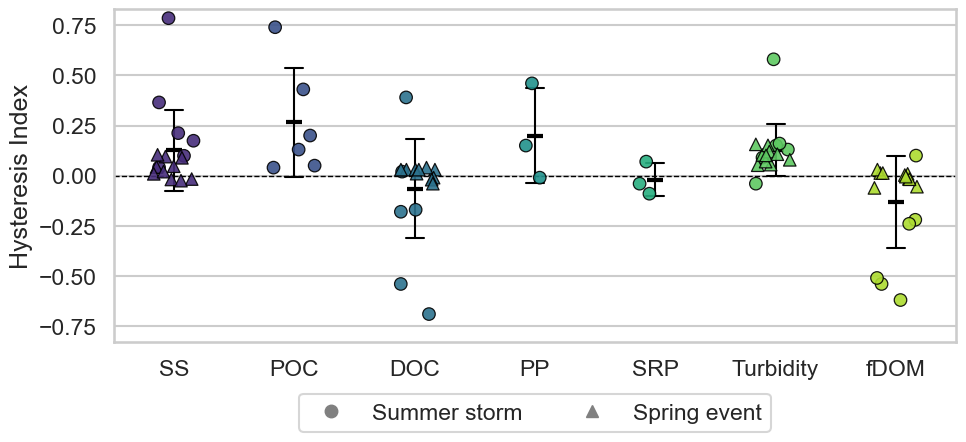

In [3]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)
x_positions = {constituent: i for i, constituent in enumerate(constituents)}# numeric positions for each constituent
np.random.seed(42)  # reproducible jitter

# individual HI values with: color = constituent and marker = event type
for event_type, marker in marker_dict.items():
    subset = df_long[df_long["event_type"] == event_type].copy()

    x = subset["constituent"].map(x_positions).astype(float)
    x_jittered = x + np.random.uniform(-0.18, 0.18, size=len(subset))

    ax.scatter(x_jittered, subset["HI"], c=subset["constituent"].map(palette_dict), marker=marker, alpha=0.9, edgecolor="black", linewidth=0.9, label=event_type, zorder=3)

# mean and standard deviation error bars
sns.pointplot(data=df_long, x="constituent", y="HI", color="black", estimator="mean", errorbar="sd",    
            linestyles="none", dodge=False, markers="_", markersize=12, capsize=0.15, legend=False, err_kws={"linewidth": 1.5}, ax=ax, zorder=2)
# zero reference line
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=1, zorder=1)

# axis formatting
ax.set_xticks(range(len(constituents)))
ax.set_xticklabels(constituents)
ax.set_xlabel("")
ax.set_ylabel("Hysteresis Index")

# symbol legend only
symbol_legend = [
    Line2D([0], [0], marker=marker_dict["Summer storm"], color="gray", linestyle="None", markersize=9, label="Summer storm"),
    Line2D([0], [0], marker=marker_dict["Spring event"], color="gray", linestyle="None", markersize=9, label="Spring event")]

# place legend outside the plot, centered below the x-axis label
ax.legend(handles=symbol_legend, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
# leave extra space at the bottom for the outside legend
ax.set_ylim(-0.83, 0.83)
plt.tight_layout()
fig.subplots_adjust(bottom=0.28)

plt.show()

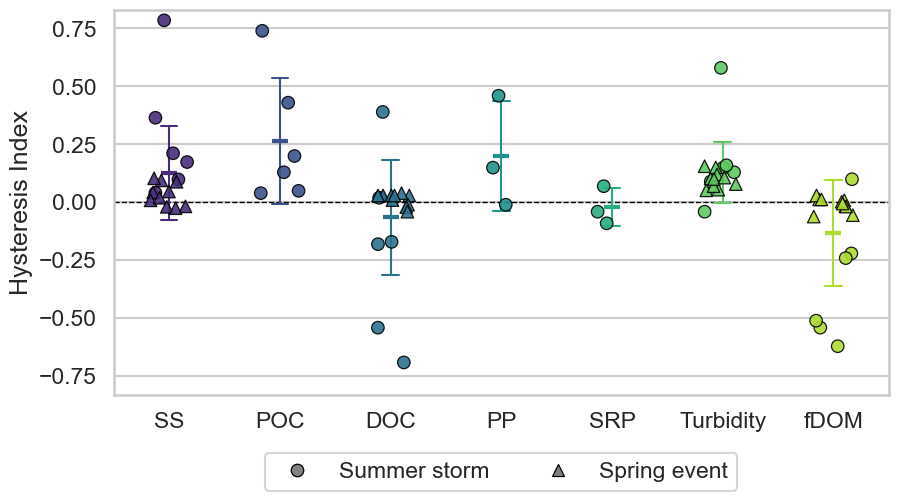

In [4]:
sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_axisbelow(True)
x_positions = {constituent: i for i, constituent in enumerate(constituents)}# numeric positions for each constituent
np.random.seed(42)  # reproducible jitter

# individual HI values with: color = constituent and marker = event type
for event_type, marker in marker_dict.items():
    subset = df_long[df_long["event_type"] == event_type].copy()

    x = subset["constituent"].map(x_positions).astype(float)
    x_jittered = x + np.random.uniform(-0.18, 0.18, size=len(subset))

    ax.scatter(x_jittered, subset["HI"], c=subset["constituent"].map(palette_dict), marker=marker, alpha=0.9, edgecolor="black", linewidth=0.9, label=event_type, zorder=3)

# mean and standard deviation error bars
sns.pointplot(data=df_long, x="constituent", y="HI", hue="constituent", order=constituents, palette=palette_dict, estimator="mean", errorbar="sd",    
            linestyles="none", dodge=False, markers="_", markersize=12, capsize=0.15, legend=False, err_kws={"linewidth": 1.5}, ax=ax, zorder=2)
# zero reference line
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=1, zorder=1)

# axis formatting
ax.set_xticks(range(len(constituents)))
ax.set_xticklabels(constituents)
ax.set_xlabel("")
ax.set_ylabel("Hysteresis Index")

# symbol legend only
symbol_legend = [
    Line2D([0], [0], marker=marker_dict["Summer storm"], color="gray", linestyle="None", markersize=9, label="Summer storm", markeredgecolor="black", markeredgewidth=0.9),
    Line2D([0], [0], marker=marker_dict["Spring event"], color="gray", linestyle="None", markersize=9, label="Spring event", markeredgecolor="black", markeredgewidth=0.9)]

# place legend outside the plot, centered below the x-axis label
ax.legend(handles=symbol_legend, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
# leave extra space at the bottom for the outside legend
ax.set_ylim(-0.83, 0.83)
#plt.tight_layout()
#fig.subplots_adjust(bottom=0.28)
plt.savefig("figure4.png", dpi=400, bbox_inches="tight")
plt.show()